In [1]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
import warnings
from pathlib import Path
import sys
import os
from datetime import datetime

project_root = Path.cwd().parent.parent
project_root_str = str(project_root)

if project_root_str not in sys.path:
    sys.path.insert(0, project_root_str)

os.chdir(project_root_str)

from src.pipeline.features.rpm_features import RPM_FEATURES, build_rpm_dataset

warnings.filterwarnings("ignore")


In [2]:
pd.set_option("display.max_columns", None)

# Local CSV path (skip slow Supabase gold reads). Features built via rpm_features.build_rpm_dataset.
# Cache engineered frame so re-runs are instant.

CACHE_PATH = Path("data/cache/rpm_from_csv.parquet")
FORCE_REBUILD = False  # set True after changing rpm_features.py


def load_season_csv(tag: str) -> pd.DataFrame:
    season = pd.read_csv(
        f"data/raw/season_stats/{tag}.csv", low_memory=False
    ).sort_values("GAME_DATE")
    playoff_path = Path(f"data/raw/playoff_stats/P{tag[1:]}.csv")
    if playoff_path.exists():
        playoffs = pd.read_csv(playoff_path, low_memory=False).sort_values("GAME_DATE")
        # Guard: P26 is currently a mislabeled full-season dump (~26k rows).
        if len(playoffs) > 5_000:
            print(
                f"  skip {playoff_path.name}: {len(playoffs):,} rows "
                "looks like a season file, not playoffs"
            )
        else:
            season = pd.concat([season, playoffs], ignore_index=True)
    return season


if CACHE_PATH.exists() and not FORCE_REBUILD:
    df = pd.read_parquet(CACHE_PATH)
    df["GAME_DATE"] = pd.to_datetime(df["GAME_DATE"])
    print(f"Loaded cache {CACHE_PATH}: {df.shape[0]:,} rows × {df.shape[1]} cols")
else:
    season_tags = ["S22", "S23", "S24", "S25", "S26"]
    season_dfs = []
    for tag in season_tags:
        part = load_season_csv(tag)
        print(f"  {tag}: {len(part):,} raw rows")
        season_dfs.append(part)

    print("Building RPM features (this can take a few minutes)...")
    df = build_rpm_dataset(season_dfs)
    df["GAME_DATE"] = pd.to_datetime(df["GAME_DATE"])
    df = df.sort_values("GAME_DATE").reset_index(drop=True)

    CACHE_PATH.parent.mkdir(parents=True, exist_ok=True)
    df.to_parquet(CACHE_PATH, index=False)
    print(f"Wrote {CACHE_PATH}: {df.shape[0]:,} rows × {df.shape[1]} cols")

df.sample(5)


Loaded cache data\cache\rpm_from_csv.parquet: 122,218 rows × 440 cols


,Unnamed: 0.3,Unnamed: 0.2,Unnamed: 0.1,SEASON_YEAR,PLAYER_ID,PLAYER_NAME,NICKNAME,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,MATCHUP,WL,MIN,FGM,FGA,FG_PCT,FG3M,FG3A,FG3_PCT,FTM,FTA,FT_PCT,OREB,DREB,REB,AST,TOV,STL,BLK,BLKA,PF,PFD,PTS,PLUS_MINUS,NBA_FANTASY_PTS,DD2,TD3,WNBA_FANTASY_PTS,AVAILABLE_FLAG,MIN_SEC,TEAM_COUNT,E_OFF_RATING,OFF_RATING,sp_work_OFF_RATING,E_DEF_RATING,DEF_RATING,sp_work_DEF_RATING,E_NET_RATING,NET_RATING,sp_work_NET_RATING,AST_PCT,AST_TO,AST_RATIO,OREB_PCT,DREB_PCT,REB_PCT,TM_TOV_PCT,E_TOV_PCT,EFG_PCT,TS_PCT,USG_PCT,E_USG_PCT,E_PACE,PACE,PACE_PER40,sp_work_PACE,PIE,POSS,FGM_PG,FGA_PG,START_POSITION,SPD,DIST,ORBC,DRBC,RBC,TCHS,SAST,FTAST,PASS,CFGM,CFGA,CFG_PCT,UFGM,UFGA,UFG_PCT,DFGM,DFGA,DFG_PCT,TEAM_FGM,TEAM_FGA,TEAM_FG_PCT,TEAM_FG3M,TEAM_FG3A,TEAM_FG3_PCT,TEAM_FTM,TEAM_FTA,TEAM_FT_PCT,TEAM_OREB,TEAM_DREB,TEAM_REB,TEAM_AST,TEAM_TOV,TEAM_STL,TEAM_BLK,TEAM_BLKA,TEAM_PF,TEAM_PFD,TEAM_PTS,TEAM_PLUS_MINUS,TEAM_E_OFF_RATING,TEAM_OFF_RATING,TEAM_E_DEF_RATING,TEAM_DEF_RATING,TEAM_E_NET_RATING,TEAM_NET_RATING,TEAM_AST_PCT,TEAM_AST_TO,TEAM_AST_RATIO,TEAM_OREB_PCT,TEAM_DREB_PCT,TEAM_REB_PCT,TEAM_TM_TOV_PCT,TEAM_EFG_PCT,TEAM_TS_PCT,TEAM_E_PACE,TEAM_PACE,TEAM_PACE_PER40,TEAM_POSS,TEAM_PIE,OPP_TEAM_ID,OPP_OPP_ABBREVIATION_base,OPP_OPP_NAME_base,OPP_FGM,OPP_FGA,OPP_FG_PCT,OPP_FG3M,OPP_FG3A,OPP_FG3_PCT,OPP_FTM,OPP_FTA,OPP_FT_PCT,OPP_OREB,OPP_DREB,OPP_REB,OPP_AST,OPP_TOV,OPP_STL,OPP_BLK,OPP_BLKA,OPP_PF,OPP_PFD,OPP_PTS,OPP_PLUS_MINUS,OPP_E_OFF_RATING,OPP_OFF_RATING,OPP_E_DEF_RATING,OPP_DEF_RATING,OPP_E_NET_RATING,OPP_NET_RATING,OPP_AST_PCT,OPP_AST_TO,OPP_AST_RATIO,OPP_OREB_PCT,OPP_DREB_PCT,OPP_REB_PCT,OPP_TM_TOV_PCT,OPP_EFG_PCT,OPP_TS_PCT,OPP_E_PACE,OPP_PACE,OPP_PACE_PER40,OPP_POSS,OPP_PIE,IS_PLAYOFF,POS,AGE,TEAM_SPREAD_ODDS,GAME_TOTAL_ODDS,TEAM_SPREAD,GAME_TOTAL,STARTING,PTS_PER_MIN,AST_PER_MIN,REB_PER_MIN,IS_HOME,POSITION_ENCODED,DAYS_REST,IS_BACK_TO_BACK,GAMES_PLAYED_THIS_SEASON,GAMES_PLAYED_CAREER,STARTING_rate_last10,player_REB_roll5_mean,player_REB_roll5_std,player_REB_roll10_mean,player_REB_roll10_std,player_REB_roll20_mean,player_REB_roll20_std,player_REB_ewma,player_REB_expanding_mean,player_REB_PER_MIN_roll5_mean,player_REB_PER_MIN_roll5_std,player_REB_PER_MIN_roll10_mean,player_REB_PER_MIN_roll10_std,player_REB_PER_MIN_roll20_mean,player_REB_PER_MIN_roll20_std,player_REB_PER_MIN_ewma,player_REB_PER_MIN_expanding_mean,player_OREB_roll5_mean,player_OREB_roll5_std,player_OREB_roll10_mean,player_OREB_roll10_std,player_OREB_roll20_mean,player_OREB_roll20_std,player_OREB_ewma,player_OREB_expanding_mean,player_DREB_roll5_mean,player_DREB_roll5_std,player_DREB_roll10_mean,player_DREB_roll10_std,player_DREB_roll20_mean,player_DREB_roll20_std,player_DREB_ewma,player_DREB_expanding_mean,player_OREB_PCT_roll5_mean,player_OREB_PCT_roll5_std,player_OREB_PCT_roll10_mean,player_OREB_PCT_roll10_std,player_OREB_PCT_roll20_mean,player_OREB_PCT_roll20_std,player_OREB_PCT_ewma,player_OREB_PCT_expanding_mean,player_DREB_PCT_roll5_mean,player_DREB_PCT_roll5_std,player_DREB_PCT_roll10_mean,player_DREB_PCT_roll10_std,player_DREB_PCT_roll20_mean,player_DREB_PCT_roll20_std,player_DREB_PCT_ewma,player_DREB_PCT_expanding_mean,player_REB_PCT_roll5_mean,player_REB_PCT_roll5_std,player_REB_PCT_roll10_mean,player_REB_PCT_roll10_std,player_REB_PCT_roll20_mean,player_REB_PCT_roll20_std,player_REB_PCT_ewma,player_REB_PCT_expanding_mean,player_ORBC_roll5_mean,player_ORBC_roll5_std,player_ORBC_roll10_mean,player_ORBC_roll10_std,player_ORBC_roll20_mean,player_ORBC_roll20_std,player_ORBC_ewma,player_ORBC_expanding_mean,player_DRBC_roll5_mean,player_DRBC_roll5_std,player_DRBC_roll10_mean,player_DRBC_roll10_std,player_DRBC_roll20_mean,player_DRBC_roll20_std,player_DRBC_ewma,player_DRBC_expanding_mean,player_RBC_roll5_mean,player_RBC_roll5_std,player_RBC_roll10_mean,player_RBC_roll10_std,player_RBC_roll20_mean,player_RBC_roll20_std,player_RBC_ewma,player_RBC_expanding_mean,player_MIN_roll5_mean,player_MIN_roll5_std,player_MIN_roll10_mean,play

In [3]:
print(df.shape)
print(df["SEASON"].value_counts().sort_index())


(122218, 440)
SEASON
S22    25198
S23    24889
S24    24697
S25    23616
S26    23818
Name: count, dtype: int64


In [4]:
# Feature list from src.pipeline.features.rpm_features
FEATURE_COLS = list(RPM_FEATURES)

missing = [c for c in FEATURE_COLS if c not in df.columns]
if missing:
    raise KeyError(
        f"RPM_FEATURES missing from engineered df ({len(missing)}): {missing[:20]}"
        + ("..." if len(missing) > 20 else "")
    )

print(f"Features ({len(FEATURE_COLS)})")
df[FEATURE_COLS].dtypes


Features (22)


player_REB_PER_MIN_ewma              float64
player_REB_PER_MIN_expanding_mean    float64
player_REB_PER_MIN_season_mean       float64
player_REB_PER_MIN_roll5_mean        float64
player_REB_PER_MIN_roll10_mean       float64
player_REB_PCT_season_mean           float64
player_REB_PCT_roll10_mean           float64
player_OREB_PCT_roll10_mean          float64
player_DREB_PCT_season_mean          float64
player_DREB_PCT_roll10_mean          float64
player_ORBC_roll10_mean              float64
player_RBC_roll10_mean               float64
player_DRBC_roll10_mean              float64
player_MIN_roll10_mean               float64
player_MIN_roll5_mean                float64
player_MIN_season_mean               float64
RBC_TREND_5v20                       float64
DRBC_TREND_5v20                      float64
POSITION_ENCODED                       int64
STARTING_rate_last10                 float64
opp_team_TEAM_REB_PCT_roll10_mean    float64
DAYS_REST                            float64
dtype: obj

In [5]:
# ── Train/holdout split ───────────────────────────────────────────────────────
# CHANGED: S26 is held out entirely. The model never sees it during training
# or hyperparameter evaluation. Evaluate on it ONCE at the very end.

HOLDOUT_SEASON = "S26"
ID_COLS = ["GAME_ID", "PLAYER_ID", "SEASON", "PLAYER_NAME", "GAME_DATE"]
TARGET_COL = "REB_PER_MIN"
ROLE_COL = "STARTING"

df_model = df[df["SEASON"] != HOLDOUT_SEASON].copy()   # S22–S25
df_holdout = df[df["SEASON"] == HOLDOUT_SEASON].copy()  # S26 blind test

KEEP_COLS = list(dict.fromkeys(
    FEATURE_COLS + ID_COLS + [TARGET_COL, ROLE_COL, "MIN"]
))

rpm_df = (
    df_model[KEEP_COLS]
    .sort_values("GAME_DATE")
    .reset_index(drop=True)
)

rpm_holdout = (
    df_holdout[KEEP_COLS]
    .sort_values("GAME_DATE")
    .reset_index(drop=True)
)

X = rpm_df[FEATURE_COLS].copy()
y = rpm_df[TARGET_COL]

print(f"Train pool (S22–S25) : {len(rpm_df):,} rows")
print(f"Holdout   (S26)      : {len(rpm_holdout):,} rows")
print(f"Date range (train)   : {rpm_df['GAME_DATE'].min().date()} → {rpm_df['GAME_DATE'].max().date()}")
print(f"Date range (holdout) : {rpm_holdout['GAME_DATE'].min().date()} → {rpm_holdout['GAME_DATE'].max().date()}")


Train pool (S22–S25) : 98,400 rows
Holdout   (S26)      : 23,818 rows
Date range (train)   : 2021-10-19 → 2025-06-22
Date range (holdout) : 2025-10-21 → 2026-05-11


In [6]:
from sklearn.model_selection import TimeSeriesSplit

quantiles = [0.10, 0.50, 0.90]

XGB_PARAMS = dict(
    objective             = "reg:quantileerror",
    n_estimators          = 1344,
    max_depth             = 3,
    learning_rate         = 0.0199208375412252,
    subsample             = 0.6525095024077675,
    colsample_bytree      = 0.7424913081435832,
    reg_alpha             = 3.890568820995351,
    reg_lambda            = 4.755281357016035,
    min_child_weight      = 10,
    n_jobs                = -1,
    random_state          = 42,
    early_stopping_rounds = 50,
)


def fit_quantile_models(X_train, y_train, X_val, y_val):
    """Train one XGB quantile model per quantile, return preds dict."""
    models = {}
    preds  = {}
    for q in quantiles:
        m = XGBRegressor(**XGB_PARAMS, quantile_alpha=q)
        m.fit(X_train, y_train,
              eval_set=[(X_val, y_val)],
              verbose=False)
        key         = f"q_{q:.2f}"
        models[key] = m
        preds[key]  = m.predict(X_val)
    return models, preds

In [7]:
# ── Helpers ───────────────────────────────────────────────────────────────────

RPM_TIERS = {
    "<0.15 reb/min":    lambda a: a < 0.15,
    "0.15-0.25 reb/min": lambda a: (a >= 0.15) & (a < 0.25),
    "0.25-0.40 reb/min": lambda a: (a >= 0.25) & (a < 0.40),
    "0.40+ reb/min":    lambda a: a >= 0.40,
}


def score_fold(actual, preds, models, fold_label, starting=None):
    """
    Score a single fold.
    CHANGED: now accepts `starting` (bool/int array) and reports
    stratified MAE + coverage across roles and RPM tiers.
    Pass `starting` from `rpm_df` / `rpm_holdout` aligned to the validation rows
    (`STARTING` may not be included in RPM_FEATURES).
    """
    lower  = preds["q_0.10"]
    median = preds["q_0.50"]
    upper  = preds["q_0.90"]

    mae      = mean_absolute_error(actual, median)
    r2       = r2_score(actual, median)
    coverage = np.mean((actual >= lower) & (actual <= upper))

    metrics = {
        "fold":           fold_label,
        "n":              len(actual),
        "mae":            mae,
        "r2":             r2,
        "coverage_80pct": coverage,
        "best_iters":     {k: models[k].best_iteration for k in models},
    }

    print(f"\n{fold_label}")
    print(f"  Overall  | n={len(actual):5d} | MAE: {mae:.4f} | R²: {r2:.3f} | 80% Coverage: {coverage:.1%}")

    # ── Role stratification (starter vs bench) ────────────────────────────────
    if starting is not None:
        for role, mask in [("Starters", starting == 1), ("Bench", starting == 0)]:
            if mask.sum() == 0:
                continue
            r_mae = mean_absolute_error(actual[mask], median[mask])
            r_cov = np.mean((actual[mask] >= lower[mask]) & (actual[mask] <= upper[mask]))
            metrics[f"mae_{role}"]      = r_mae
            metrics[f"coverage_{role}"] = r_cov
            print(f"  {role:10s} | n={mask.sum():5d} | MAE: {r_mae:.4f} | Coverage: {r_cov:.1%}")

    # ── RPM-tier stratification ────────────────────────────────────────────────
    for tier, fn in RPM_TIERS.items():
        mask = fn(actual)
        if mask.sum() == 0:
            continue
        t_mae = mean_absolute_error(actual[mask], median[mask])
        t_cov = np.mean((actual[mask] >= lower[mask]) & (actual[mask] <= upper[mask]))
        metrics[f"mae_{tier}"]      = t_mae
        metrics[f"coverage_{tier}"] = t_cov
        print(f"  {tier:20s} | n={mask.sum():5d} | MAE: {t_mae:.4f} | Coverage: {t_cov:.1%}")

    return metrics


# ════════════════════════════════════════════════════════════════════════════
# PHASE 1 — TimeSeriesSplit (feature selection / hyperparam comparison only)
# ════════════════════════════════════════════════════════════════════════════

print("── Phase 1: TimeSeriesSplit ─────────────────────────────────────────")
tscv         = TimeSeriesSplit(n_splits=5)
tscv_results = []

for fold, (train_idx, val_idx) in enumerate(tscv.split(X)):
    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
    starting_val = rpm_df.iloc[val_idx]["STARTING"].values

    models, preds = fit_quantile_models(X_tr, y_tr, X_val, y_val)
    metrics = score_fold(y_val.values, preds, models,
                         f"TSCV fold {fold+1}", starting=starting_val)
    tscv_results.append(metrics)

maes = [r["mae"]            for r in tscv_results]
r2s  = [r["r2"]             for r in tscv_results]
covs = [r["coverage_80pct"] for r in tscv_results]
print(f"\nTimeSeriesSplit Summary")
print(f"  MAE      : {np.mean(maes):.4f} ± {np.std(maes):.4f}")
print(f"  R²       : {np.mean(r2s):.3f}  ± {np.std(r2s):.3f}")
print(f"  Coverage : {np.mean(covs):.1%} ± {np.std(covs):.1%}  (target ~80%)")


# ════════════════════════════════════════════════════════════════════════════
# PHASE 2 — Walk-Forward (date-based, production simulation)
#
# CHANGED: splits are now on unique GAME_DATEs, not row indices.
# This ensures no single game date is split across train/val,
# which was the root cause of intra-game leakage in the original code.
# ════════════════════════════════════════════════════════════════════════════

print("\n── Phase 2: Walk-Forward Validation (date-based) ───────────────────")

assert rpm_df["GAME_DATE"].is_monotonic_increasing, "rpm_df must be sorted by GAME_DATE"

unique_dates = rpm_df["GAME_DATE"].unique()          # sorted unique game dates
n_dates      = len(unique_dates)

TRAIN_WINDOW = round(n_dates * 0.50)                 # dates in each training window
STEP_SIZE    = round(n_dates * 0.10)                 # dates to advance each fold
N_FOLDS      = 4

print(f"Unique game dates in pool : {n_dates}")
print(f"Training window           : {TRAIN_WINDOW} dates (~{TRAIN_WINDOW/n_dates:.0%})")
print(f"Step size                 : {STEP_SIZE} dates (~{STEP_SIZE/n_dates:.0%})")

wf_results  = []
models_last = None   # will hold the final fold's models for downstream cells

for fold in range(N_FOLDS):
    d_train_start = fold * STEP_SIZE
    d_train_end   = d_train_start + TRAIN_WINDOW
    d_val_end     = d_train_end   + STEP_SIZE

    if d_val_end > n_dates:
        print(f"\nFold {fold+1}: not enough dates remaining — stopping at {fold} folds.")
        break

    train_dates = unique_dates[d_train_start:d_train_end]
    val_dates   = unique_dates[d_train_end:d_val_end]

    # CHANGED: mask on dates so every player in a given game date
    # lands on the same side of the split — no intra-game leakage.
    train_mask = rpm_df["GAME_DATE"].isin(train_dates)
    val_mask   = rpm_df["GAME_DATE"].isin(val_dates)

    X_tr,  X_val  = X[train_mask], X[val_mask]
    y_tr,  y_val  = y[train_mask], y[val_mask]
    starting_val  = rpm_df.loc[val_mask, "STARTING"].values

    label = (f"WF fold {fold+1}  "
             f"({train_dates[-1].date()} → {val_dates[-1].date()})")

    models, preds = fit_quantile_models(X_tr, y_tr, X_val, y_val)
    metrics = score_fold(y_val.values, preds, models, label, starting=starting_val)
    metrics.update({
        "train_start": train_dates[0],
        "train_end":   train_dates[-1],
        "val_end":     val_dates[-1],
        # stash masks so downstream cells can reconstruct without retraining
        "train_mask":  train_mask,
        "val_mask":    val_mask,
    })
    wf_results.append(metrics)

    # keep last fold for residual plots + SHAP
    models_last   = models
    preds_last    = preds
    X_val_last    = X_val
    y_val_last    = y_val
    starting_last = starting_val

# ── Walk-forward summary ──────────────────────────────────────────────────────
maes = [r["mae"]            for r in wf_results]
r2s  = [r["r2"]             for r in wf_results]
covs = [r["coverage_80pct"] for r in wf_results]

print(f"\n{'─'*60}")
print(f"Walk-Forward Summary ({len(wf_results)}/{N_FOLDS} folds)")
print(f"  MAE      : {np.mean(maes):.4f} ± {np.std(maes):.4f}")
print(f"  R²       : {np.mean(r2s):.3f}  ± {np.std(r2s):.3f}")
print(f"  Coverage : {np.mean(covs):.1%} ± {np.std(covs):.1%}  (target ~80%)")

# CHANGED: per-fold coverage table — catches folds where interval collapses
# or over-covers without hiding it in the mean.
print(f"\n{'─'*60}")
print("Per-fold coverage breakdown (target 80%):")
print(f"  {'Fold':<45} {'Coverage':>10}  {'Starters':>10}  {'Bench':>10}")
for r in wf_results:
    s_cov = r.get("coverage_Starters", float('nan'))
    b_cov = r.get("coverage_Bench",    float('nan'))
    print(f"  {r['fold']:<45} {r['coverage_80pct']:>9.1%}  {s_cov:>9.1%}  {b_cov:>9.1%}")

# CHANGED: stratified MAE summary across all folds
print(f"\nPer-fold MAE by RPM tier:")
tier_keys = list(RPM_TIERS.keys())
header = f"  {'Fold':<45} " + "  ".join(f"{t:>20}" for t in tier_keys)
print(header)
for r in wf_results:
    row = f"  {r['fold']:<45} "
    row += "  ".join(f"{r.get(f'mae_{t}', float('nan')):>20.4f}" for t in tier_keys)
    print(row)

# Drift check
max_mae = max(maes)
print(f"\nMAE over folds (stable = good, rising = model aging):")
for r in wf_results:
    bar = "█" * int((r["mae"] / max_mae) * 20)
    print(f"  {r['fold']:<45} {r['mae']:.4f}  {bar}")

last_fold = wf_results[-1]

── Phase 1: TimeSeriesSplit ─────────────────────────────────────────

TSCV fold 1
  Overall  | n=16400 | MAE: 0.0715 | R²: 0.395 | 80% Coverage: 79.5%
  Starters   | n= 9176 | MAE: 0.0657 | Coverage: 80.5%
  Bench      | n= 7224 | MAE: 0.0789 | Coverage: 78.4%
  <0.15 reb/min        | n= 7642 | MAE: 0.0606 | Coverage: 77.1%
  0.15-0.25 reb/min    | n= 4872 | MAE: 0.0554 | Coverage: 92.5%
  0.25-0.40 reb/min    | n= 2961 | MAE: 0.0897 | Coverage: 76.4%
  0.40+ reb/min        | n=  925 | MAE: 0.1886 | Coverage: 41.7%

TSCV fold 2
  Overall  | n=16400 | MAE: 0.0700 | R²: 0.419 | 80% Coverage: 79.8%
  Starters   | n= 9218 | MAE: 0.0637 | Coverage: 81.0%
  Bench      | n= 7182 | MAE: 0.0782 | Coverage: 78.3%
  <0.15 reb/min        | n= 7661 | MAE: 0.0560 | Coverage: 79.4%
  0.15-0.25 reb/min    | n= 4781 | MAE: 0.0563 | Coverage: 91.0%
  0.25-0.40 reb/min    | n= 2984 | MAE: 0.0882 | Coverage: 74.6%
  0.40+ reb/min        | n=  974 | MAE: 0.1921 | Coverage: 44.6%

TSCV fold 3
  Overall  | 

In [8]:
# import optuna
# from sklearn.model_selection import TimeSeriesSplit
# from sklearn.metrics import mean_absolute_error
# from xgboost import XGBRegressor

# tscv = TimeSeriesSplit(n_splits=3)  # fewer splits = faster tuning

# def objective(trial):
#     params = {
#         "objective": "reg:quantileerror",
#         "n_estimators": trial.suggest_int("n_estimators", 500, 2000),
#         "max_depth": trial.suggest_int("max_depth", 3, 12),
#         "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
#         "subsample": trial.suggest_float("subsample", 0.5, 1.0),
#         "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
#         "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 5.0, log=True),
#         "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 5.0, log=True),
#         "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
#         "n_jobs": -1,
#         "random_state": 42,
#         "early_stopping_rounds": 50,
#     }
#     maes = []
#     for train_idx, val_idx in tscv.split(X):
#         X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
#         y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
#         m = XGBRegressor(**params, quantile_alpha=0.5)
#         m.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
#         pred = m.predict(X_val)
#         maes.append(mean_absolute_error(y_val, pred))
#     return float(np.mean(maes))

# study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=42))
# study.optimize(objective, n_trials=50, show_progress_bar=True)

# print("Best MAE (mean over TSCV, median model):", study.best_value)
# print("Best params:", study.best_params)

### Residual Visuals

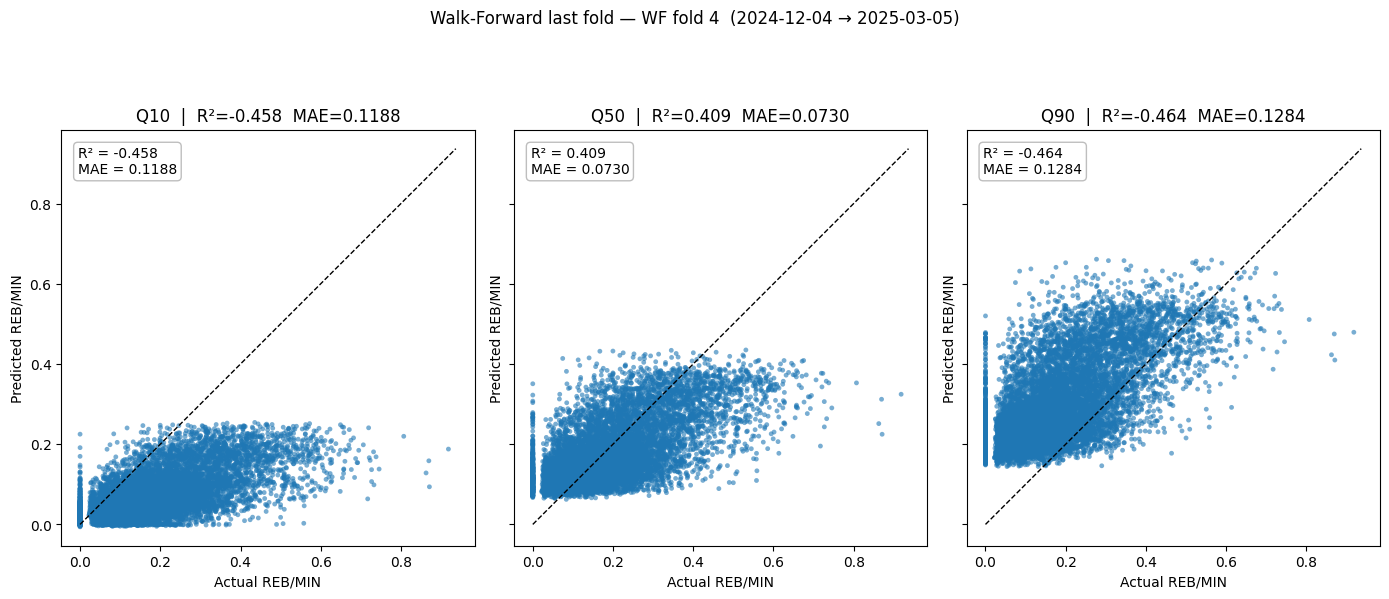

Per-quantile fit on last validation fold:
  Q10: R²=-0.458  MAE=0.1188
  Q50: R²=+0.409  MAE=0.0730
  Q90: R²=-0.464  MAE=0.1284

Coverage per quantile (should match quantile value):
  Q10: 9.9%  (target 10%, delta -0.1%)  ✓
  Q50: 48.8%  (target 50%, delta -1.2%)  ✓
  Q90: 89.0%  (target 90%, delta -1.0%)  ✓

80% interval width (Q10→Q90):
  mean   : 0.2281 reb/min
  median : 0.2133 reb/min
  std    : 0.0617 reb/min


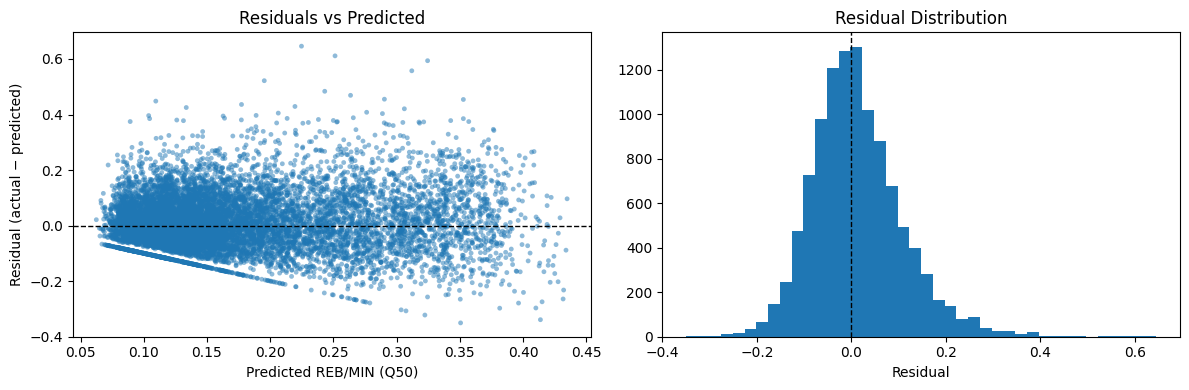


Residual summary:
  mean bias : +0.0119  (close to 0 = unbiased)
  std       : 0.0962

Residuals by role:
  Starters   | n= 6020 | bias=+0.0094 | std=0.0871
  Bench      | n= 4852 | bias=+0.0150 | std=0.1063

Residuals by RPM tier:
  <0.15 reb/min        | n= 4965 | bias=-0.0491 | std=0.0558
  0.15-0.25 reb/min    | n= 3160 | bias=+0.0214 | std=0.0652
  0.25-0.40 reb/min    | n= 1998 | bias=+0.0808 | std=0.0774
  0.40+ reb/min        | n=  749 | bias=+0.1925 | std=0.0970


In [9]:
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_absolute_error

# ── pull directly from stored walk-forward variables ─────────────────────────
# models_last, preds_last, X_val_last, y_val_last, starting_last
# are all set at the end of the walk-forward loop — no reconstruction needed.

y_true    = y_val_last.values
pred_low  = preds_last["q_0.10"]
pred_mid  = preds_last["q_0.50"]
pred_high = preds_last["q_0.90"]

preds_plot = {"Q10": pred_low, "Q50": pred_mid, "Q90": pred_high}

# ── predicted vs actual scatter ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 6), sharex=True, sharey=True)
scatter_metrics = {}

for ax, (name, y_pred) in zip(axes, preds_plot.items()):
    r2  = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    scatter_metrics[name] = {"R2": r2, "MAE": mae}

    ax.scatter(y_true, y_pred, s=12, alpha=0.6, edgecolors="none")
    lims = [0, max(y_true.max(), y_pred.max()) * 1.02]
    ax.plot(lims, lims, "k--", lw=1)
    ax.set_title(f"{name}  |  R²={r2:.3f}  MAE={mae:.4f}")
    ax.set_xlabel("Actual REB/MIN")
    ax.set_ylabel("Predicted REB/MIN")
    ax.set_aspect("equal", adjustable="box")
    ax.text(
        0.04, 0.96,
        f"R² = {r2:.3f}\nMAE = {mae:.4f}",
        transform=ax.transAxes,
        ha="left", va="top",
        fontsize=10,
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.85, edgecolor="0.7"),
    )

plt.suptitle(f"Walk-Forward last fold — {last_fold['fold']}", y=1.02)
plt.tight_layout()
plt.show()

print("Per-quantile fit on last validation fold:")
for name, m in scatter_metrics.items():
    print(f"  {name}: R²={m['R2']:+.3f}  MAE={m['MAE']:.4f}")

# ── coverage per quantile ─────────────────────────────────────────────────────
print("\nCoverage per quantile (should match quantile value):")
for name, y_pred in preds_plot.items():
    coverage = (y_true <= y_pred).mean()
    q_target = {"Q10": 0.10, "Q50": 0.50, "Q90": 0.90}[name]
    delta    = coverage - q_target
    flag     = "⚠" if abs(delta) > 0.05 else "✓"
    print(f"  {name}: {coverage:.1%}  (target {q_target:.0%}, delta {delta:+.1%})  {flag}")

# ── interval width ────────────────────────────────────────────────────────────
interval_width = pred_high - pred_low
print(f"\n80% interval width (Q10→Q90):")
print(f"  mean   : {interval_width.mean():.4f} reb/min")
print(f"  median : {np.median(interval_width):.4f} reb/min")
print(f"  std    : {interval_width.std():.4f} reb/min")

# ── residual plot ─────────────────────────────────────────────────────────────
residuals = y_true - pred_mid
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(pred_mid, residuals, s=12, alpha=0.5, edgecolors="none")
axes[0].axhline(0, color="k", lw=1, linestyle="--")
axes[0].set_xlabel("Predicted REB/MIN (Q50)")
axes[0].set_ylabel("Residual (actual − predicted)")
axes[0].set_title("Residuals vs Predicted")

axes[1].hist(residuals, bins=40, edgecolor="none")
axes[1].axvline(0, color="k", lw=1, linestyle="--")
axes[1].set_xlabel("Residual")
axes[1].set_title("Residual Distribution")

plt.tight_layout()
plt.show()

print(f"\nResidual summary:")
print(f"  mean bias : {residuals.mean():+.4f}  (close to 0 = unbiased)")
print(f"  std       : {residuals.std():.4f}")

# ── residuals stratified by role and RPM tier ─────────────────────────────────
starting_last = rpm_df.loc[X_val_last.index, "STARTING"].values

print("\nResiduals by role:")
for role, mask in [("Starters", starting_last == 1), ("Bench", starting_last == 0)]:
    if mask.sum() == 0:
        continue
    r = residuals[mask]
    print(f"  {role:10s} | n={mask.sum():5d} | bias={r.mean():+.4f} | std={r.std():.4f}")

print("\nResiduals by RPM tier:")
for tier, fn in RPM_TIERS.items():
    mask = fn(y_true)
    if mask.sum() == 0:
        continue
    r = residuals[mask]
    print(f"  {tier:20s} | n={mask.sum():5d} | bias={r.mean():+.4f} | std={r.std():.4f}")


── q_0.10 ──


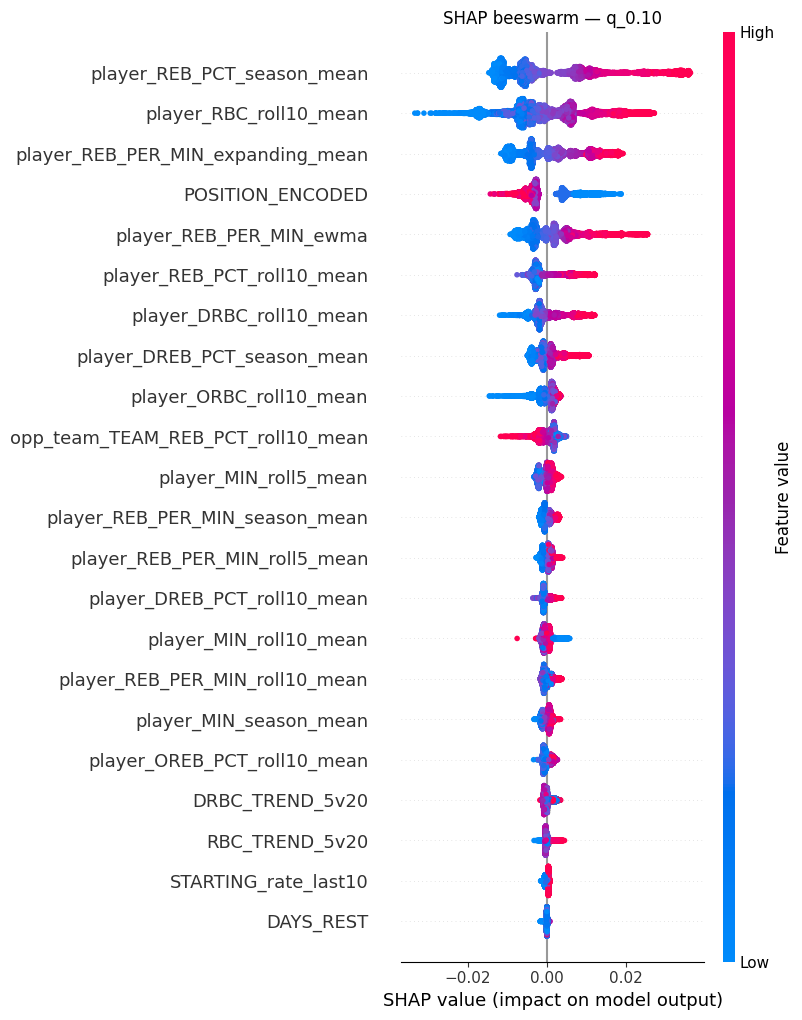


── q_0.50 ──


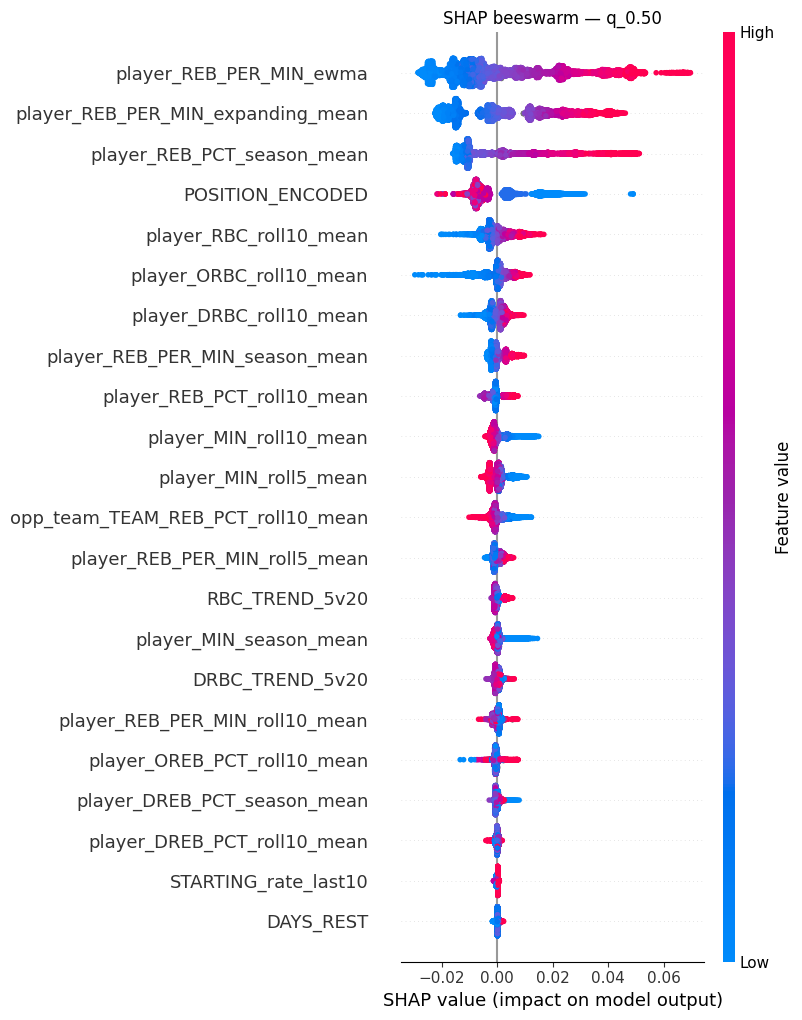


── q_0.90 ──


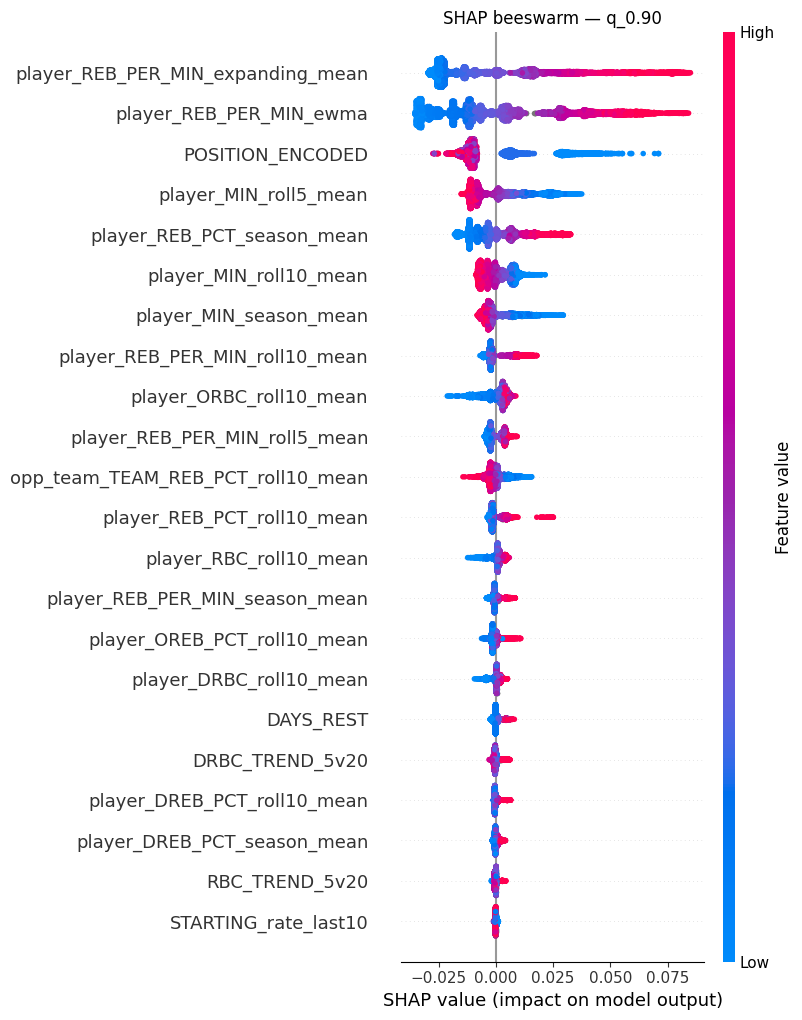

In [10]:
import shap

for q_key, model in models_last.items():
    explainer   = shap.TreeExplainer(model, model_output="raw")
    shap_values = explainer(X_val_last)

    print(f"\n── {q_key} ──")
    shap.plots.beeswarm(shap_values, max_display=30, show=False)
    plt.title(f"SHAP beeswarm — {q_key}")
    plt.tight_layout()
    plt.show()

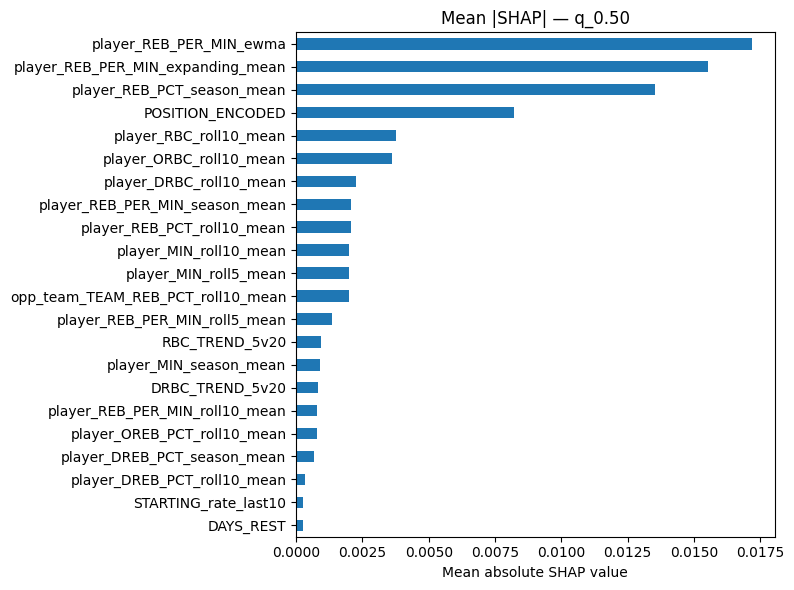

In [11]:
model = models_last["q_0.50"]

explainer   = shap.TreeExplainer(model, model_output="raw")
shap_values = explainer(X_val_last)

mean_abs_shap = np.abs(shap_values.values).mean(axis=0)
feat_imp = pd.Series(mean_abs_shap, index=FEATURE_COLS).sort_values(ascending=True)

ax = feat_imp.plot(kind="barh", figsize=(8, 6))
ax.set_title("Mean |SHAP| — q_0.50")
ax.set_xlabel("Mean absolute SHAP value")
plt.tight_layout()
plt.show()


In [12]:
# ── Permutation importance — on VALIDATION set ───────────────────────────────
from sklearn.inspection import permutation_importance
from sklearn.metrics import make_scorer
from scipy import stats as sp_stats

def pinball_50(y_true, y_pred, alpha=0.50):
    residual = y_true - y_pred
    return -np.mean(np.where(residual >= 0, alpha * residual, (alpha - 1) * residual))

result = permutation_importance(
    models_last["q_0.50"],
    X_val_last,
    y_val_last,
    n_repeats=30,
    random_state=42,
    scoring=make_scorer(pinball_50),
)

pi_df = (
    pd.DataFrame({
        "feature":    X_val_last.columns,
        "importance": result.importances_mean,
        "std":        result.importances_std,
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)
pi_df.index += 1
pi_df["importance"] = pi_df["importance"].round(6)
pi_df["std"]        = pi_df["std"].round(6)

pi_df["p_value"] = sp_stats.ttest_1samp(
    result.importances, 0.0, axis=1
).pvalue.round(4)
pi_df["significant"] = pi_df["p_value"] < 0.05

print("Permutation importance (val set) — higher = more important, significant = p<0.05")
print(pi_df.to_string())

Permutation importance (val set) — higher = more important, significant = p<0.05
                              feature  importance       std  p_value  significant
1             player_REB_PER_MIN_ewma    0.002085  0.000085    0.000         True
2   player_REB_PER_MIN_expanding_mean    0.001412  0.000071    0.000         True
3          player_REB_PCT_season_mean    0.001312  0.000058    0.000         True
4                    POSITION_ENCODED    0.000473  0.000038    0.000         True
5             player_ORBC_roll10_mean    0.000292  0.000040    0.000         True
6              player_RBC_roll10_mean    0.000271  0.000025    0.000         True
7          player_REB_PCT_roll10_mean    0.000118  0.000012    0.000         True
8         player_OREB_PCT_roll10_mean    0.000095  0.000014    0.000         True
9             player_DRBC_roll10_mean    0.000081  0.000017    0.000         True
10     player_REB_PER_MIN_season_mean    0.000081  0.000011    0.000         True
11             pl

In [13]:
from sklearn.metrics import mean_squared_error

# ── pull train/val slices from last fold's stored masks ───────────────────────
train_mask_last = last_fold["train_mask"]
val_mask_last   = last_fold["val_mask"]

X_tr_last = X[train_mask_last]
X_va_last = X[val_mask_last]
y_tr_last = y[train_mask_last]
y_va_last = y[val_mask_last]


def rmse_median_ablation(feature_cols):
    m = XGBRegressor(**XGB_PARAMS, quantile_alpha=0.50)
    m.fit(
        X_tr_last[feature_cols], y_tr_last,
        eval_set=[(X_va_last[feature_cols], y_va_last)],
        verbose=False,
    )
    pred = m.predict(X_va_last[feature_cols])
    return float(np.sqrt(mean_squared_error(y_va_last, pred)))


baseline_rmse = rmse_median_ablation(FEATURE_COLS)
print(f"Baseline RMSE (all features): {baseline_rmse:.6f}")

rows = []
for feat in FEATURE_COLS:
    cols         = [c for c in FEATURE_COLS if c != feat]
    ablated_rmse = rmse_median_ablation(cols)
    delta        = ablated_rmse - baseline_rmse  # positive = removing it hurt = feature helped
    rows.append({"feature": feat, "ablated_rmse": round(ablated_rmse, 6), "delta_rmse": round(delta, 6)})

ablation_df = (
    pd.DataFrame(rows)
    .sort_values("delta_rmse", ascending=False)
    .reset_index(drop=True)
)
ablation_df.index += 1
print(ablation_df.to_string())


Baseline RMSE (all features): 0.096915
                              feature  ablated_rmse  delta_rmse
1                    POSITION_ENCODED      0.096994    0.000079
2   opp_team_TEAM_REB_PCT_roll10_mean      0.096956    0.000041
3             player_ORBC_roll10_mean      0.096944    0.000029
4              player_RBC_roll10_mean      0.096924    0.000009
5              player_MIN_roll10_mean      0.096913   -0.000002
6         player_OREB_PCT_roll10_mean      0.096905   -0.000010
7       player_REB_PER_MIN_roll5_mean      0.096882   -0.000033
8         player_DREB_PCT_roll10_mean      0.096879   -0.000036
9                     DRBC_TREND_5v20      0.096878   -0.000037
10            player_REB_PER_MIN_ewma      0.096870   -0.000045
11                          DAYS_REST      0.096866   -0.000049
12             player_MIN_season_mean      0.096866   -0.000049
13              player_MIN_roll5_mean      0.096859   -0.000056
14        player_DREB_PCT_season_mean      0.096858   -0.000057
1

In [14]:
from scipy import stats

# ── all three methods use the val set for consistency ─────────────────────────
model = models_last["q_0.50"]

_shap_expl     = shap.TreeExplainer(model, model_output="raw")
_shap_vals     = _shap_expl(X_val_last)                        # ← val set, not X_tr
_mean_abs_shap = np.abs(_shap_vals.values).mean(axis=0)

shap_table = pd.DataFrame({
    "feature":       X_val_last.columns,
    "mean_abs_shap": _mean_abs_shap,
}).assign(
    shap_rank=lambda d: d["mean_abs_shap"].rank(method="min", ascending=False).astype(int)
)

perm_table = (
    pi_df.sort_values("importance", ascending=False)
    .reset_index(drop=True)
    .rename(columns={"importance": "perm_importance", "std": "perm_importance_std"})
)
perm_table["perm_rank"] = np.arange(1, len(perm_table) + 1)
perm_table = perm_table[["feature", "perm_rank", "perm_importance", "perm_importance_std"]]

perm_pv = pd.DataFrame({
    "feature":    X_val_last.columns,
    "perm_pvalue": stats.ttest_1samp(
        result.importances, 0.0, axis=1, nan_policy="omit"
    ).pvalue,
})

abla = ablation_df[["feature", "delta_rmse"]].rename(columns={"delta_rmse": "ablation_delta"})

feature_audit = (
    pd.DataFrame({"feature": FEATURE_COLS})
    .merge(shap_table, on="feature", how="left")
    .merge(perm_table, on="feature", how="left")
    .merge(perm_pv,    on="feature", how="left")
    .merge(abla,       on="feature", how="left")
)

_ms       = feature_audit["mean_abs_shap"].astype(float)
_mp       = feature_audit["perm_importance"].astype(float)
_max_shap = _ms.fillna(0).max()
_max_perm = _mp.fillna(0).max()

feature_audit["shap_norm"] = np.where(_max_shap > 0, _ms.fillna(0) / _max_shap, 0.0)
feature_audit["perm_norm"] = np.where(_max_perm > 0, _mp.fillna(0) / _max_perm, 0.0)
feature_audit["consensus"] = (feature_audit["shap_norm"] + feature_audit["perm_norm"]) / 2

feature_audit = feature_audit.sort_values("consensus", ascending=False).reset_index(drop=True)
feature_audit.index += 1

# flag features that are significant in perm AND positive in ablation
feature_audit["keep"] = (
    (feature_audit["perm_pvalue"] < 0.05) &
    (feature_audit["ablation_delta"] > 0)
)

print(feature_audit.to_string())


                              feature  mean_abs_shap  shap_rank  perm_rank  perm_importance  perm_importance_std   perm_pvalue  ablation_delta  shap_norm  perm_norm  consensus   keep
1             player_REB_PER_MIN_ewma       0.017183          1          1         0.002085             0.000085  8.412129e-42       -0.000045   1.000000   1.000000   1.000000  False
2   player_REB_PER_MIN_expanding_mean       0.015544          2          2         0.001412             0.000071  3.009602e-39       -0.000095   0.904598   0.677218   0.790908  False
3          player_REB_PCT_season_mean       0.013542          3          3         0.001312             0.000058  6.809092e-41       -0.000097   0.788102   0.629257   0.708679  False
4                    POSITION_ENCODED       0.008197          4          4         0.000473             0.000038  2.112337e-33        0.000079   0.477069   0.226859   0.351964   True
5             player_ORBC_roll10_mean       0.003631          6          5         0.

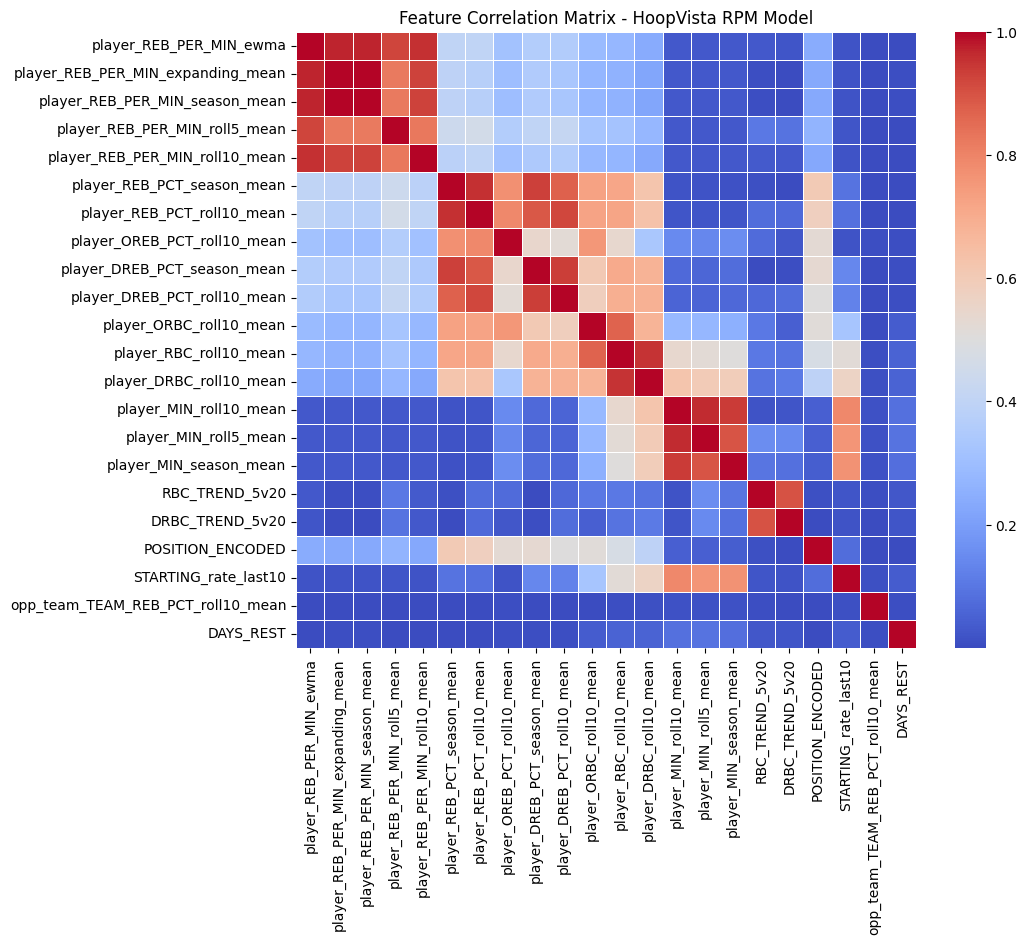

--- High Correlation Report (Threshold > 0.95) ---
player_REB_PER_MIN_season_mean <-> player_REB_PER_MIN_expanding_mean: 1.0000
player_REB_PER_MIN_expanding_mean <-> player_REB_PER_MIN_ewma: 0.9696
player_REB_PER_MIN_season_mean <-> player_REB_PER_MIN_ewma: 0.9696
player_MIN_roll5_mean <-> player_MIN_roll10_mean: 0.9643
player_REB_PER_MIN_roll10_mean <-> player_REB_PER_MIN_ewma: 0.9558
player_REB_PCT_roll10_mean <-> player_REB_PCT_season_mean: 0.9554
player_DRBC_roll10_mean <-> player_RBC_roll10_mean: 0.9515


['player_REB_PER_MIN_expanding_mean',
 'player_REB_PER_MIN_season_mean',
 'player_REB_PER_MIN_roll10_mean',
 'player_REB_PCT_roll10_mean',
 'player_DRBC_roll10_mean',
 'player_MIN_roll5_mean']

In [16]:
import seaborn as sns

def analyze_correlations(df, features, threshold=0.95):
    """
    Analyzes feature correlations to identify redundancy in the RPM model.
    """
    corr_matrix = df[features].corr().abs()

    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

    to_drop = [column for column in upper.columns if any(upper[column] > threshold)]

    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
    plt.title(f'Feature Correlation Matrix - HoopVista RPM Model')
    plt.show()

    print(f"--- High Correlation Report (Threshold > {threshold}) ---")
    high_corr_pairs = []
    for col in upper.columns:
        connected = upper.index[upper[col] > threshold].tolist()
        for c in connected:
            high_corr_pairs.append((col, c, upper.loc[c, col]))

    if not high_corr_pairs:
        print("No features exceed the correlation threshold.")
    else:
        for f1, f2, val in sorted(high_corr_pairs, key=lambda x: x[2], reverse=True):
            print(f"{f1} <-> {f2}: {val:.4f}")

    return to_drop

correlated_features = analyze_correlations(df, FEATURE_COLS)
correlated_features


In [17]:
# ════════════════════════════════════════════════════════════════════════════
# BLIND HOLDOUT TEST — S26
#
# NEW: evaluate on the season the model never saw during development.
# Run this cell once. If you iterate after seeing these numbers,
# S26 is no longer a clean holdout.
# ════════════════════════════════════════════════════════════════════════════

print("── S26 Blind Holdout Evaluation ─────────────────────────────────────")
print("  S21–S25: 90% rows for fit, last 10% for early-stopping only; predict S26 (never in eval_set).")

X_train_full = rpm_df[FEATURE_COLS]
y_train_full = rpm_df["REB_PER_MIN"]
X_ho         = rpm_holdout[FEATURE_COLS]
y_ho         = rpm_holdout["REB_PER_MIN"]
starting_ho  = rpm_holdout["STARTING"].values

# Early stopping on last 10% of training only — S26 must not be eval_set
# or best_iteration is tuned to the holdout.
es_cutoff  = int(len(X_train_full) * 0.90)
X_es_train = X_train_full.iloc[:es_cutoff]
y_es_train = y_train_full.iloc[:es_cutoff]
X_es_val   = X_train_full.iloc[es_cutoff:]
y_es_val   = y_train_full.iloc[es_cutoff:]

models_ho, _ = fit_quantile_models(X_es_train, y_es_train, X_es_val, y_es_val)
preds_ho = {k: models_ho[k].predict(X_ho) for k in models_ho}

ho_metrics = score_fold(
    y_ho.values, preds_ho, models_ho,
    "S26 Blind Holdout",
    starting=starting_ho
)

# Compare walk-forward MAE vs holdout MAE
wf_mae_mean = np.mean([r["mae"] for r in wf_results])
ho_mae      = ho_metrics["mae"]
gap         = ho_mae - wf_mae_mean

print(f"\n{'─'*55}")
print(f"  Walk-forward MAE (mean, S21–S25)  : {wf_mae_mean:.4f}")
print(f"  Holdout MAE      (S26)            : {ho_mae:.4f}")
print(f"  Gap                               : {gap:+.4f}  {'⚠ investigate' if abs(gap) > 0.05 else '✓ acceptable'}")

# Per-quantile calibration on holdout
print(f"\nHoldout quantile calibration (should match target):")
for q_key, target in [("q_0.10", 0.10), ("q_0.50", 0.50), ("q_0.90", 0.90)]:
    pred            = preds_ho[q_key]
    actual          = y_ho.values
    actual_coverage = (actual <= pred).mean()
    delta           = actual_coverage - target
    flag            = "⚠" if abs(delta) > 0.05 else "✓"
    print(f"  {q_key} | actual coverage: {actual_coverage:.1%}  target: {target:.0%}  delta: {delta:+.1%}  {flag}")

# Interval width on holdout
interval_width = preds_ho["q_0.90"] - preds_ho["q_0.10"]
print(f"\nHoldout 80% interval width (Q10→Q90):")
print(f"  mean: {interval_width.mean():.4f}  |  median: {np.median(interval_width):.4f}  |  std: {interval_width.std():.4f}")


── S26 Blind Holdout Evaluation ─────────────────────────────────────
  S21–S25: 90% rows for fit, last 10% for early-stopping only; predict S26 (never in eval_set).

S26 Blind Holdout
  Overall  | n=23818 | MAE: 0.0732 | R²: 0.370 | 80% Coverage: 79.6%
  Starters   | n=12967 | MAE: 0.0668 | Coverage: 80.8%
  Bench      | n=10851 | MAE: 0.0808 | Coverage: 78.1%
  <0.15 reb/min        | n=10966 | MAE: 0.0599 | Coverage: 79.0%
  0.15-0.25 reb/min    | n= 7065 | MAE: 0.0549 | Coverage: 92.8%
  0.25-0.40 reb/min    | n= 4390 | MAE: 0.0962 | Coverage: 71.8%
  0.40+ reb/min        | n= 1397 | MAE: 0.1970 | Coverage: 41.4%

───────────────────────────────────────────────────────
  Walk-forward MAE (mean, S21–S25)  : 0.0717
  Holdout MAE      (S26)            : 0.0732
  Gap                               : +0.0015  ✓ acceptable

Holdout quantile calibration (should match target):
  q_0.10 | actual coverage: 10.0%  target: 10%  delta: +0.0%  ✓
  q_0.50 | actual coverage: 50.3%  target: 50%  delt

In [18]:
import joblib
from pathlib import Path

# ── resolve save directory relative to this notebook ─────────────────────────
# Works on any machine regardless of OS or username.
# Structure: <repo_root>/src/models/saved_models/

REPO_ROOT = Path(__file__).resolve().parents[1] if "__file__" in dir() else Path.cwd()
save_dir  = REPO_ROOT / "src" / "models" / "saved_models"
save_dir.mkdir(parents=True, exist_ok=True)

# ── save ──────────────────────────────────────────────────────────────────────
bundle = {
    "quantile_models": models_ho,
    "feature_names":   FEATURE_COLS,
    "fold_metrics":    wf_results,
    "holdout_metrics": ho_metrics,
    "train_end":       rpm_df["GAME_DATE"].max(),
    "val_end":         rpm_holdout["GAME_DATE"].max(),
}

save_path = save_dir / f"rpm_quantile_xgb_{rpm_holdout['GAME_DATE'].max().date()}.joblib"
joblib.dump(bundle, save_path)
print(f"Saved to {save_path}")

# ── load ──────────────────────────────────────────────────────────────────────
bundle        = joblib.load(save_path)
models_loaded = bundle["quantile_models"]
feature_names = bundle["feature_names"]

test_preds = models_loaded["q_0.50"].predict(X_ho)
print(f"Loaded model MAE (S26 holdout): {mean_absolute_error(y_ho, test_preds):.4f}")
print(f"Trained on data up to        : {bundle['train_end'].date()}")
print(f"Holdout through              : {bundle['val_end'].date()}")

# ── inference ─────────────────────────────────────────────────────────────────
def predict_rpm(player_features: pd.DataFrame) -> pd.DataFrame:
    """
    Pass in a DataFrame with the same columns as FEATURE_COLS.
    Returns Q10 / Q50 / Q90 predictions per row.
    """
    assert list(player_features.columns) == feature_names, \
        f"Feature mismatch — expected {feature_names}"

    return pd.DataFrame({
        "q10": models_loaded["q_0.10"].predict(player_features),
        "q50": models_loaded["q_0.50"].predict(player_features),
        "q90": models_loaded["q_0.90"].predict(player_features),
    })


Saved to c:\Users\alexg\OneDrive\Documents\NBA-Prop-Predictor\src\models\saved_models\rpm_quantile_xgb_2026-05-11.joblib
Loaded model MAE (S26 holdout): 0.0732
Trained on data up to        : 2025-06-22
Holdout through              : 2026-05-11


In [ ]:
# Demo inference on an engineered CSV row (same columns as training).
row = rpm_holdout.iloc[[0]]
player_features = row[FEATURE_COLS]
print(row[["PLAYER_NAME", "GAME_DATE", "REB_PER_MIN"]].to_string(index=False))
print(predict_rpm(player_features))
player_features
